In [178]:
import yfinance as yf
import pandas as pd


silver = yf.download("SI=F", start = "2011-01-01")['Close']
gold = yf.download("GC=F", start = "2011-01-01")['Close']


data = pd.concat([silver, gold], axis = 1) #align indexes
data.columns = ['Silver','Gold']
data['GSR'] = data['Gold'] / data['Silver']
data = data.reset_index() 
data = data.dropna()
data



/var/folders/pp/8s7gqcrn3rscx70q717ydwzm0000gn/T/ipykernel_84067/1416862897.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  silver = yf.download("SI=F", start = "2011-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/pp/8s7gqcrn3rscx70q717ydwzm0000gn/T/ipykernel_84067/1416862897.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start = "2011-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


,Date,Silver,Gold,GSR
0,2011-01-03,31.096001,1422.599976,45.748648
1,2011-01-04,29.492001,1378.500000,46.741488
2,2011-01-05,29.173000,1373.400024,47.077778
3,2011-01-06,29.110001,1371.400024,47.110958
4,2011-01-07,28.660999,1368.500000,47.747812
...,...,...,...,...
3919,2026-08-06,61.438999,4242.000000,69.044093
3920,2026-08-07,63.332001,4340.700195,68.538814
3921,2026-08-10,65.106003,4361.799805,66.995356
3922,2026-08-11,64.768997,4383.000000,67.671265


In [179]:
## Stage 1: Prediction Feature Definitions

data['Silver_Return_1D'] = data['Silver'].pct_change()
data['Silver_Return_1D']

data['Silver_Return_5D_Forward'] = (
    data['Silver'].shift(-5) / data['Silver'] - 1
)

data['Silver_Return_5D_Forward'] 
data['Silver_Momentum_20D'] = data['Silver'].pct_change(20)
data['Silver_Volatility_20D'] = (
    data['Silver_Return_1D'].rolling(20).std()
)


model_data = data.dropna(
    subset=['Silver_Return_5D_Forward', 'Silver_Momentum_20D',
    'Silver_Volatility_20D']
).copy()



model_data



,Date,Silver,Gold,GSR,Silver_Return_1D,Silver_Return_5D_Forward,Silver_Momentum_20D,Silver_Volatility_20D
20,2011-02-01,28.524000,1339.599976,46.963959,0.012423,0.061247,-0.082712,0.021483
21,2011-02-02,28.299000,1331.500000,47.051133,-0.007888,0.069755,-0.040452,0.018399
22,2011-02-03,28.733000,1352.300049,47.064353,0.015336,0.047263,-0.015082,0.018660
23,2011-02-04,29.063999,1348.300049,46.390727,0.011520,0.031930,-0.001580,0.018849
24,2011-02-07,29.348000,1347.599976,45.917950,0.009772,0.040241,0.023970,0.018598
...,...,...,...,...,...,...,...,...
3914,2026-07-30,58.814999,4100.100098,69.711812,0.016453,0.044614,-0.021137,0.024694
3915,2026-07-31,57.591000,4049.100098,70.307863,-0.020811,0.099686,-0.050327,0.024964
3916,2026-08-03,57.667000,4033.699951,69.948150,0.001320,0.128999,-0.068685,0.024376
3917,2026-08-04,60.056000,4095.399902,68.193018,0.041428,0.078477,-0.014361,0.026118


In [194]:
## Stage 2: Train-Validation-Test 
train = model_data[
    model_data['Date'] < '2021-01-01'
].copy()

validation = model_data[
    (model_data['Date'] >= '2021-01-01') &
    (model_data['Date'] < '2024-01-01')
].copy()

test = model_data[
    model_data['Date'] >= '2024-01-01'
].copy()




In [193]:
#GSR only test
X_train_gsr_only = train[['GSR']]

gsr_only_model = LinearRegression()
gsr_only_model.fit(
    X_train_gsr_only,
    train['Silver_Return_5D_Forward']
)

X_val_gsr_only = validation[['GSR']]
gsr_only_pred = gsr_only_model.predict(X_val_gsr_only)

print("MAE:", mean_absolute_error(y_val, gsr_only_pred))
print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_val, gsr_only_pred))
)
print("R^2:", r2_score(y_val, gsr_only_pred))
print(
    "Correlation:",
    np.corrcoef(y_val, gsr_only_pred)[0, 1]
)
print(
    "Directional Accuracy:",
    (np.sign(y_val) == np.sign(gsr_only_pred)).mean()
)

MAE: 0.03137007772211384
RMSE: 0.04017941931809548
R^2: 0.005038810905333646
Correlation: 0.14996432833313572
Directional Accuracy: 0.5298804780876494


In [190]:
#GSR plus feature/s on Train data
from sklearn.linear_model import LinearRegression
X_train = train[['GSR', 'Silver_Momentum_20D','Silver_Volatility_20D']]
y_train = train['Silver_Return_5D_Forward']
gsr_model = LinearRegression()
gsr_model.fit(X_train, y_train)
print(f"Intercept: {gsr_model.intercept_}")
print(f"GSR coeff: {gsr_model.coef_[0]}")
print(f"20-day silver momentum: {gsr_model.coef_[1]}")
print(f"20-day silver vol: {gsr_model.coef_[2]}")

Intercept: -0.028775255370097192
GSR coeff: 0.0003365991699946409
20-day silver momentum: -0.013937419152543736
20-day silver vol: 0.3353689936774012


In [191]:
#GSR baseline plus feats on Val Set
X_val = validation[['GSR','Silver_Momentum_20D', 'Silver_Volatility_20D']]
y_val = validation['Silver_Return_5D_Forward']

validation['GSR_Prediction'] = gsr_model.predict(X_val)

validation[
    ['Date', 'GSR', 'Silver_Return_5D_Forward', 'GSR_Prediction']
]

,Date,GSR,Silver_Return_5D_Forward,GSR_Prediction
2514,2021-01-04,71.276203,-0.074952,-0.000064
2515,2021-01-05,70.824417,-0.079322,-0.000300
2516,2021-01-06,70.696625,-0.053869,0.000547
2517,2021-01-07,70.305147,-0.053456,0.000236
2518,2021-01-08,74.611501,0.009885,0.005847
...,...,...,...,...
3262,2023-12-22,84.689173,-0.022931,0.006579
3263,2023-12-26,85.246853,-0.049619,0.006965
3264,2023-12-27,85.411278,-0.056862,0.007023
3265,2023-12-28,85.932702,-0.041933,0.007421


In [189]:
#GSR Baseline Eval Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
pred_val = validation['GSR_Prediction']
mae = mean_absolute_error(y_val, pred_val)
rmse = np.sqrt(mean_squared_error(y_val, pred_val))
r2 = r2_score(y_val, pred_val)

correlation = np.corrcoef(y_val, pred_val)[0, 1]
directional_accuracy = (
    np.sign(y_val) == np.sign(pred_val)
).mean()

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)
print("Prediction/Actual Correlation:", correlation)
print("Directional Accuracy:", directional_accuracy)

MAE: 0.03119865098733041
RMSE: 0.039980897046844904
R^2: 0.014846517977270102
Prediction/Actual Correlation: 0.21271464243183733
Directional Accuracy: 0.50199203187251


GSR exhibits weak out-of-sample predictive information, but is insufficient as a standalone forecasting model.


In [162]:
# GSR Degree 2 baseline model
train['GSR^2']= train['GSR']**2
validation['GSR^2']= validation['GSR']**2

X_train_quad = train[['GSR','GSR^2']]
y_train_quad = train['Silver_Return_5D_Forward']

quad_model = LinearRegression()
quad_model.fit(X_train_quad, y_train_quad)

print("Intercept:", quad_model.intercept_)
print("GSR coefficient:", quad_model.coef_[0])

print("GSR^2 coefficient:", quad_model.coef_[1])


X_val_quad = validation[['GSR', 'GSR^2']]
validation['Quad_Prediction'] = quad_model.predict(X_val_quad)
quad_pred = validation['Quad_Prediction']


quad_mae = mean_absolute_error(y_val, quad_pred)
quad_rmse = np.sqrt(mean_squared_error(y_val, quad_pred))
quad_r2 = r2_score(y_val, quad_pred)

quad_corr = np.corrcoef(y_val, quad_pred)[0, 1]

quad_direction = (
    np.sign(y_val) == np.sign(quad_pred)
).mean()

print("Quadratic Model")
print("MAE:", quad_mae)
print("RMSE:", quad_rmse)
print("R^2:", quad_r2)
print("Correlation:", quad_corr)
print("Directional Accuracy:", quad_direction)

Intercept: 0.05295373444235778
GSR coefficient: -0.0018712311628622145
GSR^2 coefficient: 1.540234027304203e-05
Quadratic Model
MAE: 0.03133347935702811
RMSE: 0.039884437128322806
R^2: 0.019594444970869818
Correlation: 0.16712638470442465
Directional Accuracy: 0.5179282868525896


In [197]:
#GSR Degree 2 plus feat/s training

train['GSR^2']= train['GSR']**2
validation['GSR^2']= validation['GSR']**2

X_train_quad = train[['GSR','GSR^2', 'Silver_Momentum_20D','Silver_Volatility_20D' ]]
y_train_quad = train['Silver_Return_5D_Forward']

quad_model = LinearRegression()
quad_model.fit(X_train_quad, y_train_quad)

print("Intercept:", quad_model.intercept_)
print("GSR coefficient:", quad_model.coef_[0])
print("GSR^2 coefficient:", quad_model.coef_[1])
print("20-day silver momentum coefficient:", quad_model.coef_[1])
print("20-day silver vol coefficient:", quad_model.coef_[1])

Intercept: 0.04831083932276412
GSR coefficient: -0.0017916841810260852
GSR^2 coefficient: 1.4878142058200378e-05
20-day silver momentum coefficient: 1.4878142058200378e-05
20-day silver vol coefficient: 1.4878142058200378e-05


In [198]:
#GSR degree 2 model plus feat/s evaluation

X_val_quad = validation[['GSR', 'GSR^2','Silver_Momentum_20D','Silver_Volatility_20D']]
validation['Quad_Prediction'] = quad_model.predict(X_val_quad)
quad_pred = validation['Quad_Prediction']


quad_mae = mean_absolute_error(y_val, quad_pred)
quad_rmse = np.sqrt(mean_squared_error(y_val, quad_pred))
quad_r2 = r2_score(y_val, quad_pred)

quad_corr = np.corrcoef(y_val, quad_pred)[0, 1]

quad_direction = (
    np.sign(y_val) == np.sign(quad_pred)
).mean()

print("Quadratic Model")
print("MAE:", quad_mae)
print("RMSE:", quad_rmse)
print("R^2:", quad_r2)
print("Correlation:", quad_corr)
print("Directional Accuracy:", quad_direction)

Quadratic Model
MAE: 0.031195379926486855
RMSE: 0.03972396514237052
R^2: 0.0274677479389297
Correlation: 0.19624042314268153
Directional Accuracy: 0.547144754316069


Recent 5-day DXY movement did not add incremental predictive value beyond nonlinear GSR on the 2021–2023 validation period


In [ ]:
import sympy as sp
t, g = sp.symbols('t g')
f = (83.6941840546219
     -0.005055152818705971*t
     -1.3102086683780045*g
     +1.4694800959188772e-06*t**2
     +3.906815091583157e-06*t*g
     +0.0061157421212578505*g**2)
df_dt = sp.diff(f, t)
df_dg = sp.diff(f, g)
crit_points = sp.solve([df_dt, df_dg], [t, g])
print(f"Critical points: {crit_points}")
for year in [2011, 2025]:
    low = f.subs({t: year, g: 32})
    high = f.subs({t: year, g: 126})
    print(f"Year {year}: f(32)={low:.2f}, f(126)={high:.2f}")
     
     
     
     
     







Critical points: {g: 106.613589983563, t: 1578.32462286254}
Year 2011: f(32)=44.06, f(126)=12.47
Year 2025: f(32)=44.07, f(126)=12.49


In [ ]:
#Low end Lagrange Constraint
lam = sp.symbols('lam')

# Constraint: GSR = min
constraint = g - 31.99507845731254

# Build Lagrangian
L = f + lam*(0 - constraint)

# Solve system
eqs = [sp.diff(L, t), sp.diff(L, g), sp.diff(L, lam)]
solutions = sp.solve(eqs, (t, g, lam))
solutions

{g: 31.9950784573125, lam: -0.912307623944831, t: 1677.51641448729}

In [167]:
#High end Lagrange Constraint

lam = sp.symbols('lam')

# Constraint: GSR = max
constraint = g - 125.88837597345282

# Build Lagrangian
L = f + lam*(0 - constraint)

# Solve system
eqs = [sp.diff(L, t), sp.diff(L, g), sp.diff(L, lam)]
solutions = sp.solve(eqs, (t, g, lam))
solutions


{g: 125.888375973453, lam: 0.235659139385208, t: 1552.70228711213}

In [168]:
print("GSR range:", data['GSR'].min(), "-", data['GSR'].max())

GSR range: 31.99507845731254 - 125.88837597345282


In [169]:
print(data['Silver'].idxmax())

3786


In [170]:
print(data.iloc[81])

Date                        2011-04-29 00:00:00
Silver                                   48.584
Gold                                     1556.0
GSR                                   32.027005
Silver_Return_1D                       0.022391
Silver_Return_5D_Forward              -0.273773
Silver_Momentum_20D                    0.282847
Name: 81, dtype: object


KeyError: 'Time'

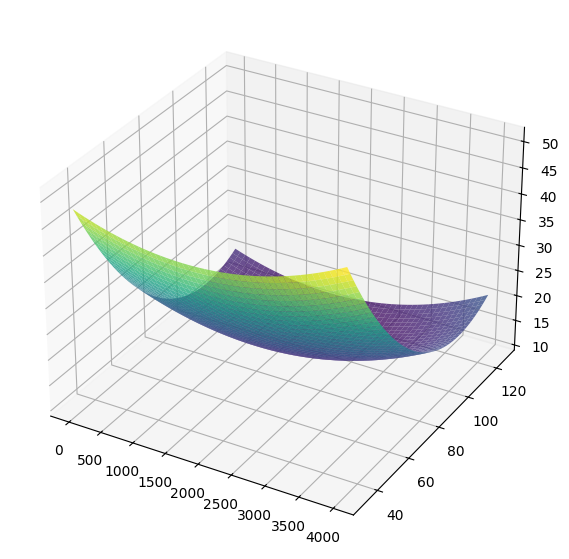

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sympy as sp

t, g = sp.symbols("t g")

f = (83.6941840546219
     -0.005055152818705971*t
     -1.3102086683780045*g
     +1.4694800959188772e-06*t**2
     +3.906815091583157e-06*t*g
     +0.0061157421212578505*g**2)

f_num = sp.lambdify((t, g), f, "numpy")

# Grid ranges
time_vals = np.linspace(0, 4000, 50)   
gsr_vals = np.linspace(32, 126, 50)

T, G = np.meshgrid(time_vals, gsr_vals)
Z = f_num(T, G)

# Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(T, G, Z, cmap="viridis", alpha=0.8)

#actual data
ax.scatter(data["Time"], data["GSR"], data["Silver"], c="red", s=15)


ax.set_xlabel("Time (days)")
ax.set_ylabel("GSR")
ax.set_zlabel("Silver Price ($)")
ax.set_title("Silver Price Surface Fit (Quadratic)")
plt.savefig("Silver_Surface.png")
plt.show()




In [104]:
import statsmodels.api as sm

X = data[['GSR']]        # GSR = gold/silver ratio
y = data['Silver']       # Silver returns

X = sm.add_constant(X) 
model = sm.OLS(y, X).fit()
print(model.summary())

ImportError: cannot import name '_lazywhere' from 'scipy._lib._util' (/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py)